In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")
import utils.data_utils as utils
import re

# Data Overview
Import the raw data. Notice that each key in the h5 file corresponds to a single cell at a single temperature.

In [59]:
hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()
keys

['/D/data_240624_ReCellML_A123_Cell01_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell03_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell05_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell06_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell07_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell08_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell09_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell11_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell12_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell14_charac_30C',
 '/D/data_240624_ReCellML_A123_Cell15_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell04_charac_30C',
 '/D/data_240626_ReCellML_A123_Cell10_charac_30C',
 '/D/data_240628_ReCellML_A123_Cell13_charac_30C',
 '/D/data_240709_ReCellML_A123_cell01_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell02_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell03_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell04_charac_45oC',
 '/D/data_240709_ReCellML_A123_cell05_charac_45oC',
 '/D/data_240709_ReCellML_

In [60]:
df = hdf.get('/D/data_240624_ReCellML_A123_Cell01_charac_30C') #convert to a dataframe
df

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
0,1.0,1,1,1,1,1,1.0,0.0,3.152,0.0,0.0,0.0,29.5,REST,6/25/2024 6:05:04 AM,,nan,NaN,NaN
1,2.0,1,1,1,1,1,2.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:05 AM,,nan,NaN,NaN
2,3.0,1,1,1,1,1,3.0,0.0,3.152,0.0,0.0,0.0,29.5,REST,6/25/2024 6:05:06 AM,,nan,NaN,NaN
3,4.0,1,1,1,1,1,4.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:07 AM,,nan,NaN,NaN
4,5.0,1,1,1,1,1,5.0,0.0,3.152,0.0,0.0,0.0,30.0,REST,6/25/2024 6:05:08 AM,,nan,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326358,493005.8,1,1,1,1,53,1760.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:17:44 PM,,nan,NaN,NaN
326359,493015.8,1,1,1,1,53,1770.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:17:54 PM,,nan,NaN,NaN
326360,493025.8,1,1,1,1,53,1780.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:18:04 PM,,nan,NaN,NaN
326361,493035.8,1,1,1,1,53,1790.0,0.0,2.883,0.0,0.0,0.0,30.0,REST,6/30/2024 11:18:14 PM,,nan,NaN,NaN


Notice that for this single cell, we have almost 500000 seconds of data, more than 5 days worth. Plotting it to see what it looks like, we have the following:

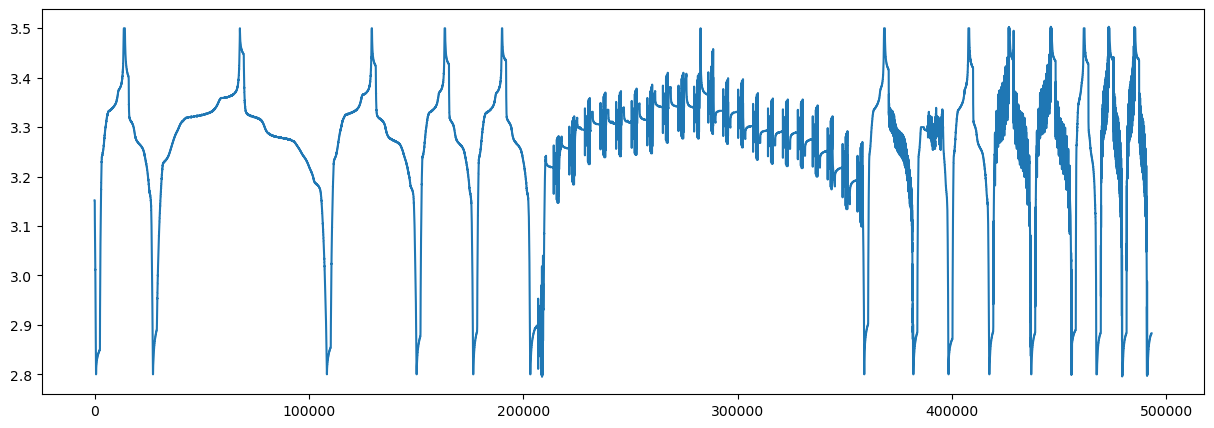

In [61]:
fig, ax = plt.subplots(figsize=(15,5))
time_data = df['Total Time, S']
v_data = df['Voltage, V']
ax.plot(time_data, v_data)

We can try manually parsing it ourselves using the segment description column to get specific sections of the data:

Text(0.5, 1.0, 'Charge Depleting Cycle p')

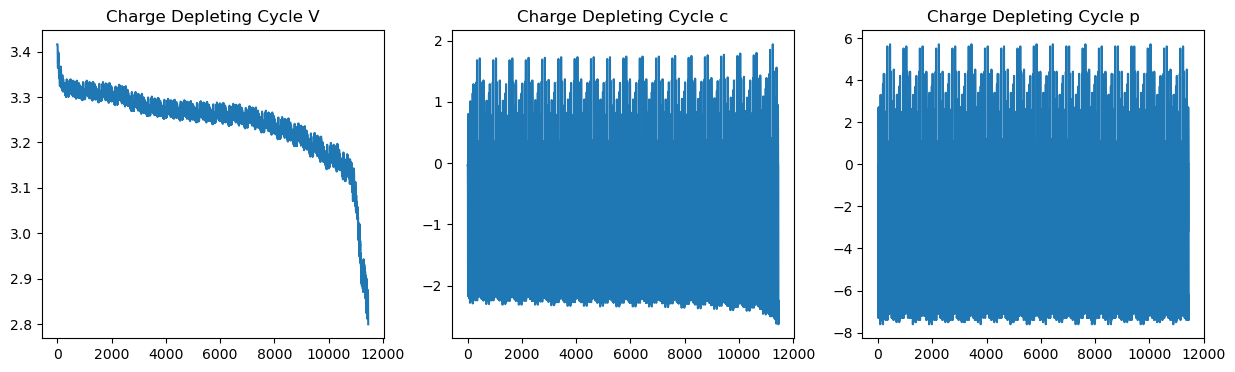

In [62]:
df_cdc = df[['Charge depleting cycle' in seg_desc for seg_desc in df['Segment Description']]]

fig, ax = plt.subplots(ncols=3, figsize=(15,4))
time_data = df_cdc['Total Time, S'] - df_cdc['Total Time, S'][267939]
v_data = df_cdc['Voltage, V']
c_data = df_cdc['Current, A']
p_data = df_cdc['Power, W']

ax[0].plot(time_data, v_data)
ax[0].set_title('Charge Depleting Cycle V')

ax[1].plot(time_data, c_data)
ax[1].set_title('Charge Depleting Cycle c')

ax[2].plot(time_data, p_data)
ax[2].set_title('Charge Depleting Cycle p')

This is a pain to do, especially to collate specific pulse types across all cell types. Luckily, this has been done for us, using the `data_for_ml.h5` file instead.

In [63]:
hdf = pd.HDFStore('../../data/data_for_ml.h5', mode='r')
ml_keys = hdf.keys()
ml_keys

['/DCIR',
 '/Dynamic_PsRP_1_1C',
 '/Dynamic_PsRP_2_1C',
 '/Static_HPPC',
 '/Static_PsRP_1',
 '/Static_PsRP_2_Chg',
 '/Static_PsRP_2_Dis',
 '/Static_Rapid',
 '/Dynamic_PsRP_2_C/2',
 '/Dynamic_PsRP_1_C/2']

Notice that these keys are organized by overall pulse type instead of by cell id.

In [64]:
df = hdf.get('/Dynamic_PsRP_1_1C')
df

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


These are organized into 120 second pulses, labeled by the type of pulse, and in the case of the dynamic pulses (which occured while charging the battery), the specific charge rate. Below is a convenient graph of an example of each pulse type. Notice the DCIR graph is blank, because DCIR is not a pulse type, but a measure of internal resistance of the battery.

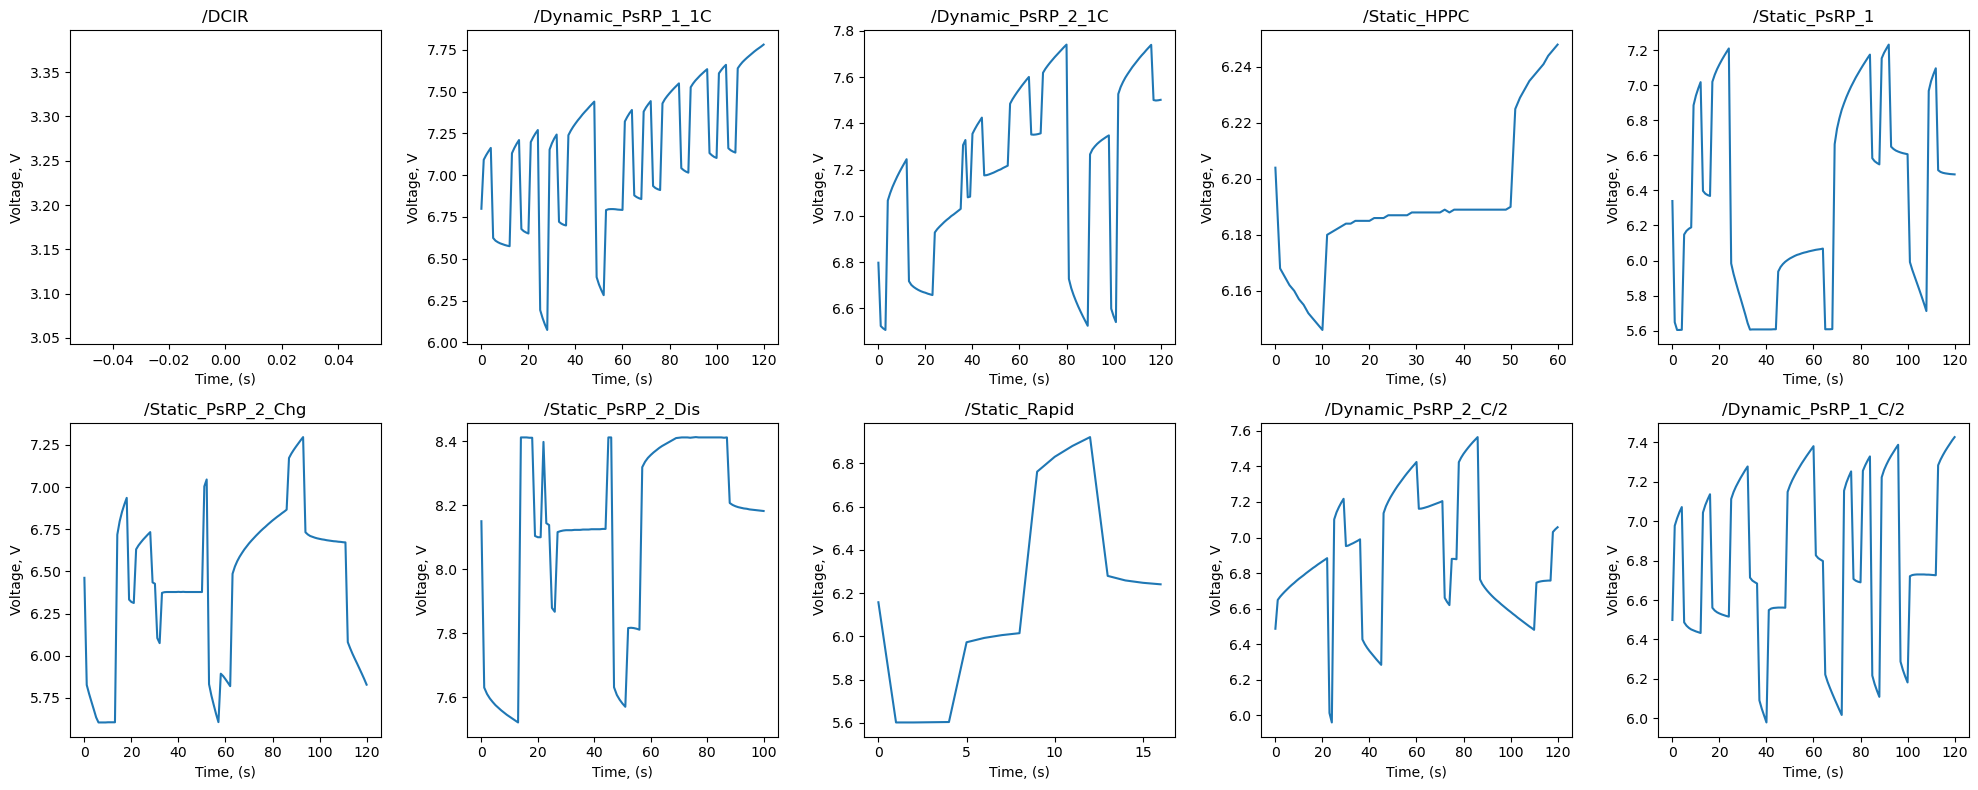

In [82]:
# with pd.option_context('display.max_rows', None):
fig, ax = plt.subplots(2,5, figsize=(20,8))
ax = ax.flatten()
for i, key in enumerate(ml_keys):
    #get voltage from one battery for each pulse type
    df = hdf.get(key)
    # target = df.loc[df['cell_id'].str.contains('D')].loc[:, 'C/10 discharge capacity']
    target = df.iloc[0].filter(regex='voltage', axis=0)
    ax[i].plot(range(len(target)), target)
    ax[i].set_title(key)
    ax[i].set_xlabel('Time, (s)')
    ax[i].set_ylabel('Voltage, V')
plt.tight_layout()
# target

In addition to the voltage and current data for all the pulses, there are also columns that include the precalculated targets that we are trying to predict. 

This is the full list:
- "1C discharge capacity",
- "C/10 discharge capacity",
- "C/5 discharge capacity",
- "C/3 discharge capacity",
- "C/2 discharge capacity",
- "P/3 discharge capacity",
- "Charge depleting cycle charge throughput",
- "Charge sustaining cycle charge efficiency",
- "soc",
- "Post 1C charge relaxation fit MSE",
- "1C discharge capacity_3bins",
- "Post 1C charge relaxation fit MSE_outlier",
- "C/3 discharge capacity_3bins",
- "Post C/2 charge relaxation fit MSE_outlier",
- "Post 1C or Post C/2_outlier",
- "Post 1C charge relaxation fit Max Error",
- "Post 1C charge relaxation fit Max Error_outlier",
- "Cell volume",
- "Electrode stack thickness",
- "Excess electrolyte",
- "Volume growth",
- "Thickness growth"

To get a good understanding of the relationship between the pulse data and the some of the target categories, here are some graphs demonstrating how some of the data looks.

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_25648\3506418197.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A Cells Charging Voltage Profiles Colored by SOC')

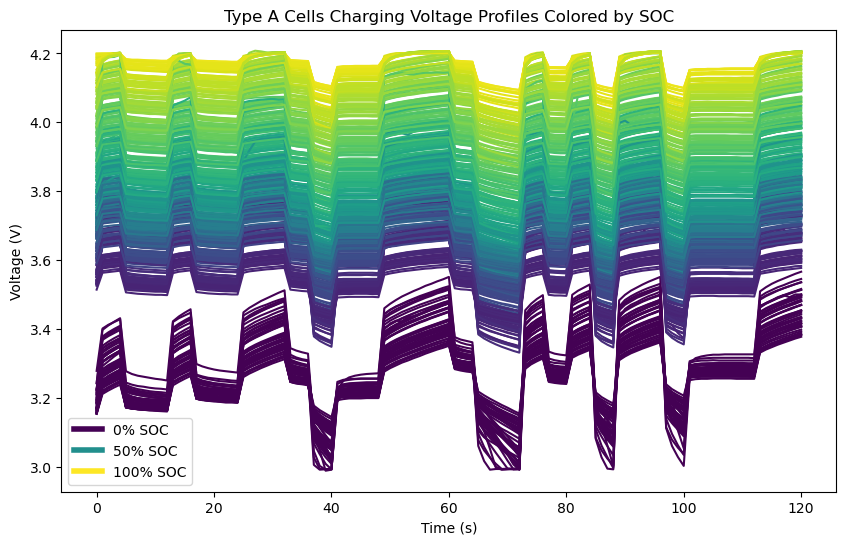

In [ ]:
import matplotlib.cm as cm

cmap = cm.get_cmap('viridis', 100)

df_a = df[df['cell_id'].str.contains('A')] #get only type A cells

charging_data=df_a.loc[df_a.direction == 'charge'] #get only charging data

plt.figure(figsize=(10,6))
for i, row in charging_data.iterrows():
    plt.plot(range(121), row.filter(regex='voltage'), c=cmap(row.soc))
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A Cells Charging Voltage Profiles Colored by SOC')

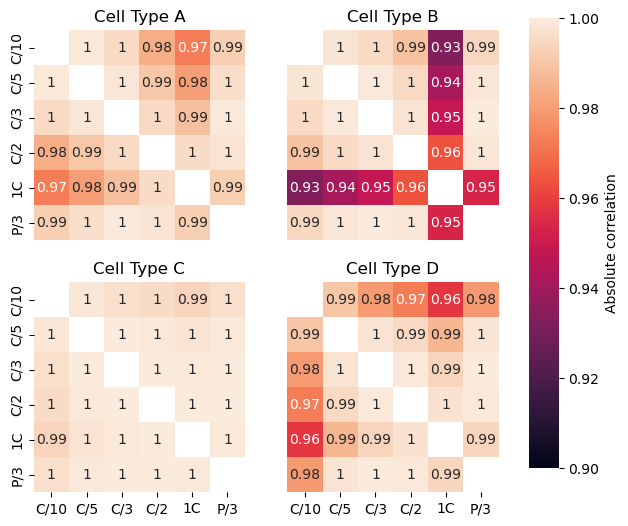

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))
ax = ax.ravel()
cax = fig.add_axes([0.95, 0.15, 0.05, 0.75]) 

vars = [
    'C/10 discharge capacity', 'C/5 discharge capacity',
    'C/3 discharge capacity', 'C/2 discharge capacity',
    '1C discharge capacity', 'P/3 discharge capacity',
    ]
labels = ['C/10', 'C/5', 'C/3', 'C/2', '1C', 'P/3']
cells = ['A', 'B', 'C', 'D']

for cell, axis in zip(cells, ax):
    corr = df.loc[df['cell_id'].str.contains(cell), vars].corr().abs()
    mask = np.zeros_like(corr)
    np.fill_diagonal(mask, 1)
    if cell == 'A':
       sns.heatmap(corr, xticklabels=[], yticklabels=labels, ax=axis, vmin=0.90, vmax=1, cbar=False, annot=True, mask=mask)
    elif cell == 'B':
       sns.heatmap(corr, xticklabels=[], yticklabels=[], ax=axis, vmin=0.90, vmax=1, cbar=False, annot=True, mask=mask)
    elif cell == 'C':
       sns.heatmap(corr, xticklabels=labels, yticklabels=labels, ax=axis, vmin=0.90, vmax=1, cbar=False, annot=True, mask=mask)
    else:
       sns.heatmap(corr, xticklabels=labels, yticklabels=[], ax=axis, vmin=0.90, vmax=1, cbar_ax=cax, cbar_kws={'label': 'Absolute correlation'}, annot=True, mask=mask)
    axis.set_title('Cell Type ' + cell)

# Exogenous Variables

There are also some exogenous variables that affect the composition of the data, including the temperature that the data was recorded at.

Text(0.5, 1.03, 'DCIR vs Capacity for Cell Type D')

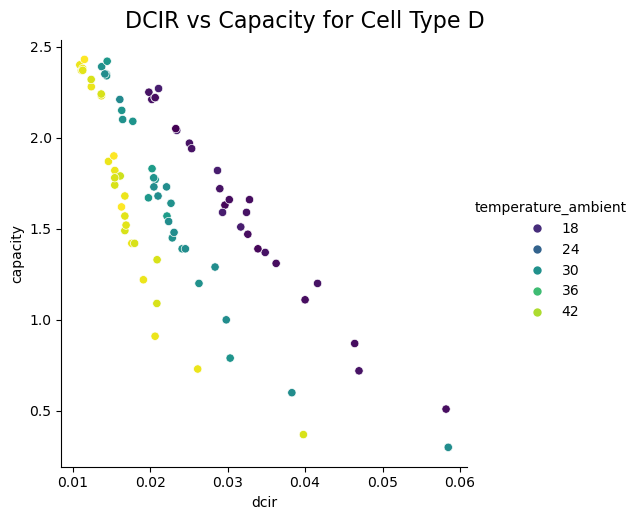

In [86]:
df_dcir = pd.read_csv('../../data/features_dcir.csv')
df_targets = pd.read_csv('../../data/targets_soh.csv')

# colate all the DCIR, capacity, and temperature values into one df
dcir = (df_dcir['charge_resistance_10s_1C_charging'] + df_dcir['discharge_resistance_10s_1C_charging'])/2
temperature = df_targets['temperature_ambient']
capcity = df_targets['1C discharge capacity']
cell_id = df_targets['cell_id']
cell_type = [id[0] for id in cell_id]
data_summary = {
    'cell_id': cell_id, 
    'cell_type': cell_type, 
    'dcir': dcir, 
    'capacity': capcity, 
    'temperature_ambient': temperature, 
}
data_summary = pd.DataFrame(data_summary)

data_summary.loc[data_summary['temperature_ambient'] < 25, 'temp_category'] = '15'
data_summary.loc[data_summary['temperature_ambient'] > 25, 'temp_category'] = '30'
data_summary.loc[data_summary['temperature_ambient'] > 38, 'temp_category'] = '45'

ax = sns.relplot(data_summary[data_summary['cell_type'] == 'D'], x='dcir', y='capacity', hue='temperature_ambient', palette='viridis')#, height=6, aspect=1.5)
ax.figure.suptitle('DCIR vs Capacity for Cell Type D', y=1.03, fontsize=16)

In [ ]:
df_pulse = hdf.get('/Static_HPPC')

mask_current = ['current' in col for col in df_pulse.columns]
mask_voltage = ['voltage' in col for col in df_pulse.columns]

currents = df_pulse.loc[:, mask_current].to_numpy()
voltages = df_pulse.loc[:, mask_voltage].to_numpy()
currents_discharge = currents[:, 0:10]
currents_charge = currents[:, 50:60]
voltages_discharge = voltages[:, 0:10]
voltages_charge = voltages[:, 50:60]

overpotentials_charge = voltages_charge - np.expand_dims(voltages_charge[:,0], 1)
instantaneous_resistances_charge = overpotentials_charge / currents_charge
resistances_charge = np.max(instantaneous_resistances_charge, 1)

overpotentials_discharge = voltages_discharge - np.expand_dims(voltages_discharge[:,0], 1)
instantaneous_resistances_discharge = overpotentials_discharge / currents_discharge
resistances_discharge = np.max(instantaneous_resistances_discharge, 1)

resistance = np.mean(np.stack((resistances_discharge, resistances_charge)), 0)

df_pulse['resistance'] = resistance


df_pulse.loc[df_pulse['temperature_ambient'] < 25, 'temp_category'] = '15'
df_pulse.loc[df_pulse['temperature_ambient'] > 25, 'temp_category'] = '30'
df_pulse.loc[df_pulse['temperature_ambient'] > 38, 'temp_category'] = '45'


C:\Users\etenney\AppData\Local\Temp\1\ipykernel_25648\364450820.py:14: RuntimeWarning: invalid value encountered in divide
  instantaneous_resistances_charge = overpotentials_charge / currents_charge
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_25648\364450820.py:18: RuntimeWarning: invalid value encountered in divide
  instantaneous_resistances_discharge = overpotentials_discharge / currents_discharge


Text(0.5, 1.0, 'resistance vs C/3 Discharge Capacity for Type A Cells')

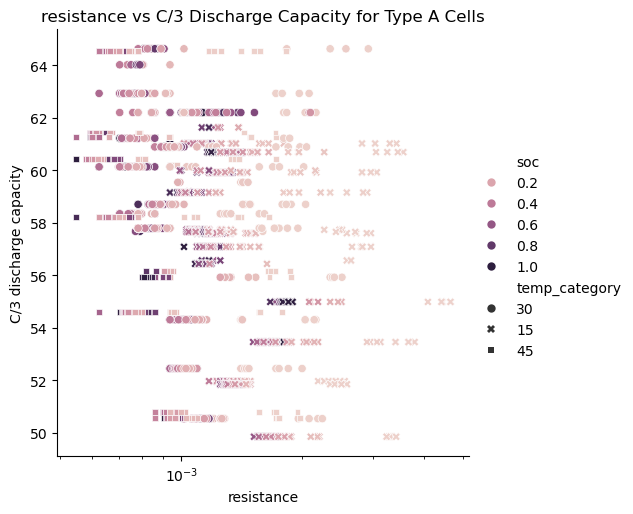

In [ ]:
plot = sns.relplot(df_pulse[df_pulse['cell_id'].str.contains('A')], x='resistance', y='C/3 discharge capacity', hue='soc', style='temp_category')
plot.axes[0][0].set_xscale('log')
plot.axes[0][0].set_title("resistance vs C/3 Discharge Capacity for Type A Cells")

Text(0.5, 1.0, 'SOC vs Resistance for Type A Cells')

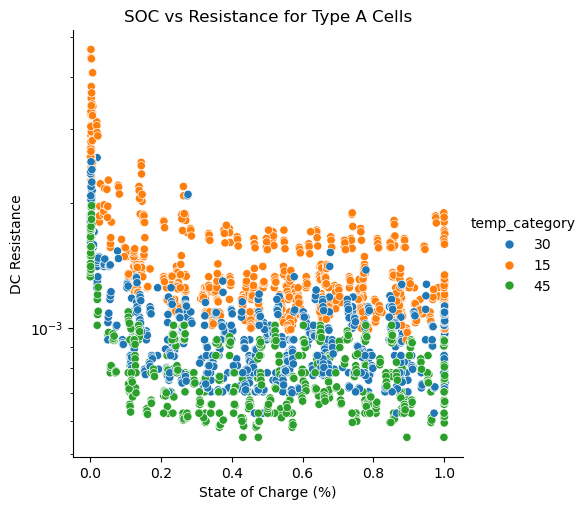

In [91]:
go = sns.relplot(df_pulse[df_pulse['cell_id'].str.contains('A')], x='soc', y='resistance', hue='temp_category')
go.axes[0][0].set_yscale('log')
go.axes[0][0].set_xlabel('State of Charge (%)')
go.axes[0][0].set_ylabel('DC Resistance')
go.axes[0][0].set_title("SOC vs Resistance for Type A Cells")

# Model Results

Our model results change depending on what we are trying to predict, and the kind of pulse data that we put in. Using the `run_bootstrap_xgboost.py` file, we can select what pulse types to use, and what targets to try to predict. For example, here are graphs showing the differences between using `Static HPPC` vs `Dynamic PsRP 1 C/2` pulse types to predict `C/3 discharge capacity` and `soc` on the four different cell types. Notice that the models trained on the dynamic pulses are uniformly better than the static pulses.

In [94]:
#helper functions

import torch
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)



def plot_true_vs_pred(pulse, target, result_dict, color='blue', n_splits=50):
    fig = plt.figure()
    df = result_dict[f"{target}, {pulse}"]
    
    average_pred = df[list(range(n_splits))].mean(axis=1)

    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color)
        # s=2)
    plt.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')

    plt.title(f"Predicting {target} from {pulse}", size='xx-large')
    plt.xlabel("Actual", size='xx-large')
    plt.ylabel("Predicted", size='xx-large')
    plt.show()
    
    if target.endswith("threshold"):
        print(classification_report(df[target], average_pred.round()))
        
    else:
        print('r2 score: ', r2_score(df[target], average_pred))
        print('mae score: ', mean_absolute_error(df[target], average_pred))
        print('max error: ', max_error(df[target], average_pred))

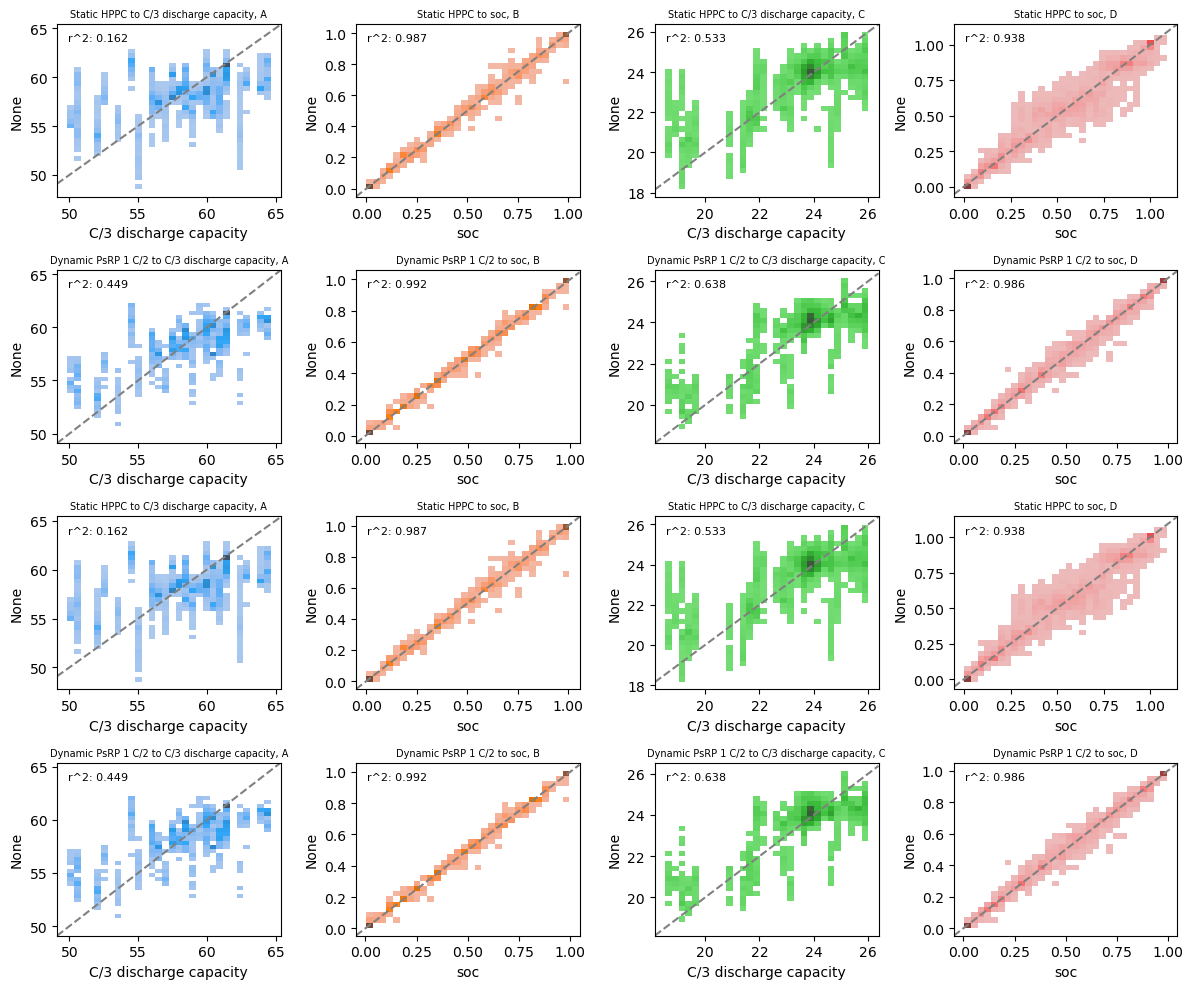

In [95]:
fig, ax = plt.subplots(4, 4, figsize=(12, 10))
ax = ax.ravel()

A = torch.load("../../results/bootstrap_results_A.pth", weights_only=False)
B = torch.load("../../results/bootstrap_results_B.pth", weights_only=False)
C = torch.load("../../results/bootstrap_results_C.pth", weights_only=False)
D = torch.load("../../results/bootstrap_results_D.pth", weights_only=False)

pulses = [
    "Static HPPC",
    "Dynamic PsRP 1 C/2",
]

targets = [
    "C/3 discharge capacity",
    "soc",
]

data = [
    A, B, C, D
]

for i in range(4):
    for j in range(4):
        plot_true_vs_pred_axis(ax[i*4 + j], pulses[i%2], targets[j%2], data[j], color=sns.color_palette("tab10")[j]) 
        ax[i*4 + j].set_title(f"{pulses[i%2]} to {targets[j%2]}, {chr(65+j)}", fontsize=7, pad=5)

plt.tight_layout()

Compare these results to the model trained on only voltage and temperature data. The r^2 correlation is monotonically worse.

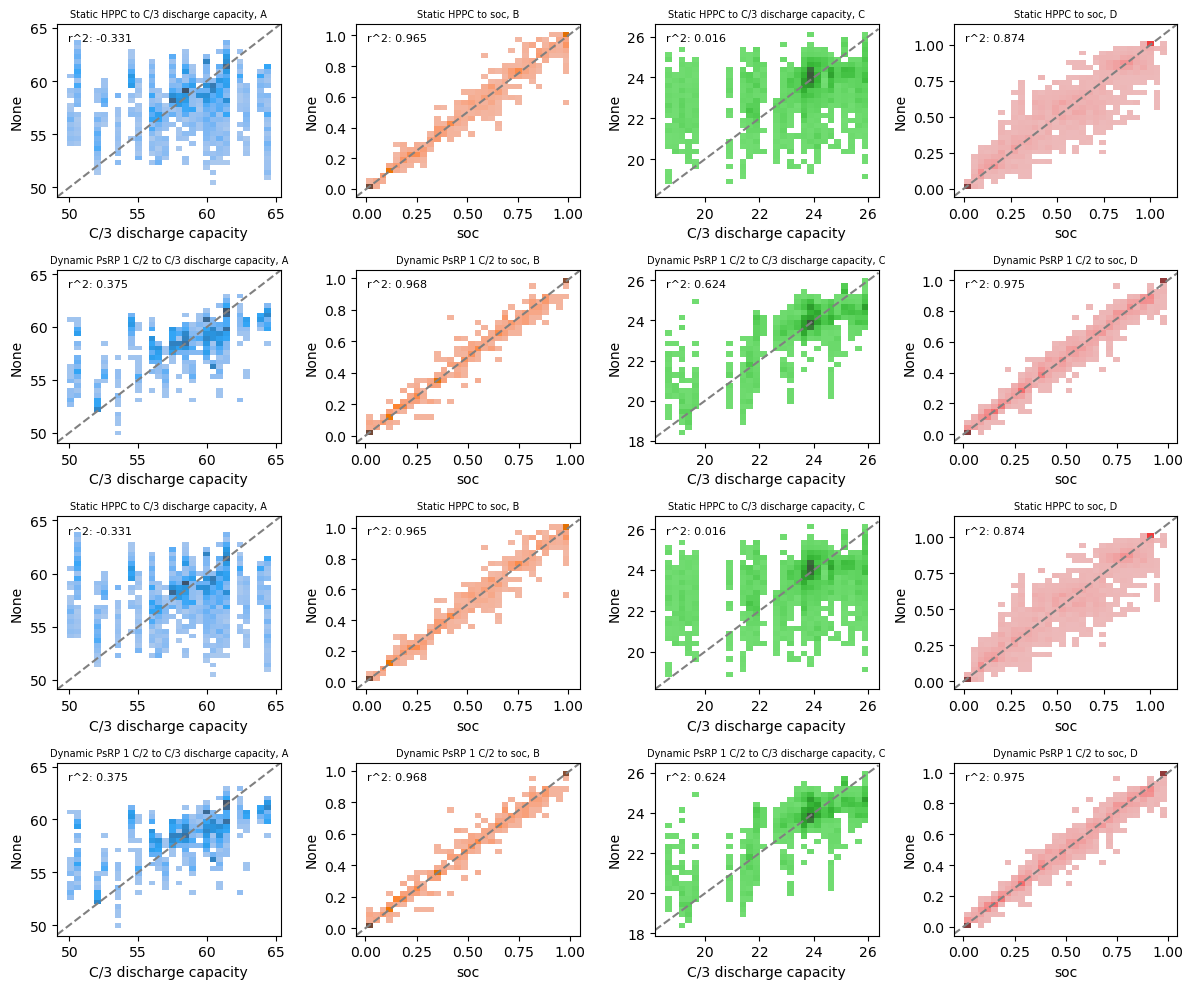

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(12, 10))
ax = ax.ravel()


A = torch.load("../../results/baseline/bootstrap_results_A.pth", weights_only=False)
B = torch.load("../../results/baseline/bootstrap_results_B.pth", weights_only=False)
C = torch.load("../../results/baseline/bootstrap_results_C.pth", weights_only=False)
D = torch.load("../../results/baseline/bootstrap_results_D.pth", weights_only=False)

data = [
    A, B, C, D
]

for i in range(4):
    for j in range(4):
        plot_true_vs_pred_axis(ax[i*4 + j], pulses[i%2], targets[j%2], data[j], color=sns.color_palette("tab10")[j]) 
        ax[i*4 + j].set_title(f"{pulses[i%2]} to {targets[j%2]}, {chr(65+j)}", fontsize=7, pad=5)
plt.tight_layout()